In [1]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
from scipy.optimize import curve_fit


In [2]:
from matplotlib.ticker import AutoMinorLocator


def apply_ax_format(ax,xlabel="",ylabel="",title="",legend=False,inset=False):
    if not inset:
        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
    ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
    ax.grid(False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    if legend:
        plt.setp(ax.get_legend().get_texts(), fontsize='22') # for legend text
        plt.setp(ax.get_legend().get_title(), fontsize='22') # for legend title



In [4]:
species_map={0:"O(SiO2)",1:"Si(SiO2)",2:"Si(Q3)",3:"O(Q3)",4:"H(Q3)",5:"Si(Q2)",6:"O(Q2)",7:"H(Q2)",8:"O(H2O)",9:"H(H2O)",10:"M(H2O)"}

df_hist_list=list()
basepath="../results/gromacs/pore/4nm/H2O/results"
for run_name in os.listdir(basepath):
    H2O=int(run_name)
    run_dir=os.path.join(basepath,run_name,"analysis")
    for rdf_dir in os.listdir(run_dir):
        if not "rdf" in rdf_dir:
            continue
        temperature=int(rdf_dir.split("_")[-1].replace("K",""))
        rdf_dir=os.path.join(run_dir,rdf_dir)
        print(rdf_dir,H2O,temperature)
        for species in species_map.keys():
            df_tmp=pd.read_csv(os.path.join(rdf_dir,"hist_%d.csv"%(species+1)),skiprows=1,skipfooter=1, engine='python',names=["Distance (nm)","count"]).query("count>0")
            df_tmp["Temperature (K)"]=temperature
            df_tmp["Species"]=species_map[species]
            df_tmp["H2O"]=H2O
            df_tmp["Force Field"]="PoreMS"
            df_tmp["norm"]=df_tmp["count"]/df_tmp["count"].max()
            df_hist_list.append(df_tmp)
df_hist_gmx=pd.concat(df_hist_list,ignore_index=True)
df_hist_gmx

../results/gromacs/pore/4nm/H2O/results\1440\analysis\rdf_100K 1440 100
../results/gromacs/pore/4nm/H2O/results\1440\analysis\rdf_200K 1440 200
../results/gromacs/pore/4nm/H2O/results\1440\analysis\rdf_300K 1440 300
../results/gromacs/pore/4nm/H2O/results\360\analysis\rdf_100K 360 100
../results/gromacs/pore/4nm/H2O/results\360\analysis\rdf_200K 360 200
../results/gromacs/pore/4nm/H2O/results\360\analysis\rdf_300K 360 300
../results/gromacs/pore/4nm/H2O/results\45\analysis\rdf_100K 45 100
../results/gromacs/pore/4nm/H2O/results\45\analysis\rdf_200K 45 200
../results/gromacs/pore/4nm/H2O/results\45\analysis\rdf_300K 45 300
../results/gromacs/pore/4nm/H2O/results\720\analysis\rdf_100K 720 100
../results/gromacs/pore/4nm/H2O/results\720\analysis\rdf_200K 720 200
../results/gromacs/pore/4nm/H2O/results\720\analysis\rdf_300K 720 300
../results/gromacs/pore/4nm/H2O/results\90\analysis\rdf_100K 90 100
../results/gromacs/pore/4nm/H2O/results\90\analysis\rdf_200K 90 200
../results/gromacs/pore/

,Distance (nm),count,Temperature (K),Species,H2O,Force Field,norm
0,1.9524,7,100,O(SiO2),1440,PoreMS,0.000016
1,1.9596,5,100,O(SiO2),1440,PoreMS,0.000011
2,1.9668,162,100,O(SiO2),1440,PoreMS,0.000363
3,1.9740,744,100,O(SiO2),1440,PoreMS,0.001665
4,1.9812,2720,100,O(SiO2),1440,PoreMS,0.006087
...,...,...,...,...,...,...,...
23993,2.2692,4,300,M(H2O),90,PoreMS,0.000154
23994,2.2764,4,300,M(H2O),90,PoreMS,0.000154
23995,2.2836,4,300,M(H2O),90,PoreMS,0.000154
23996,2.2908,5,300,M(H2O),90,PoreMS,0.000192


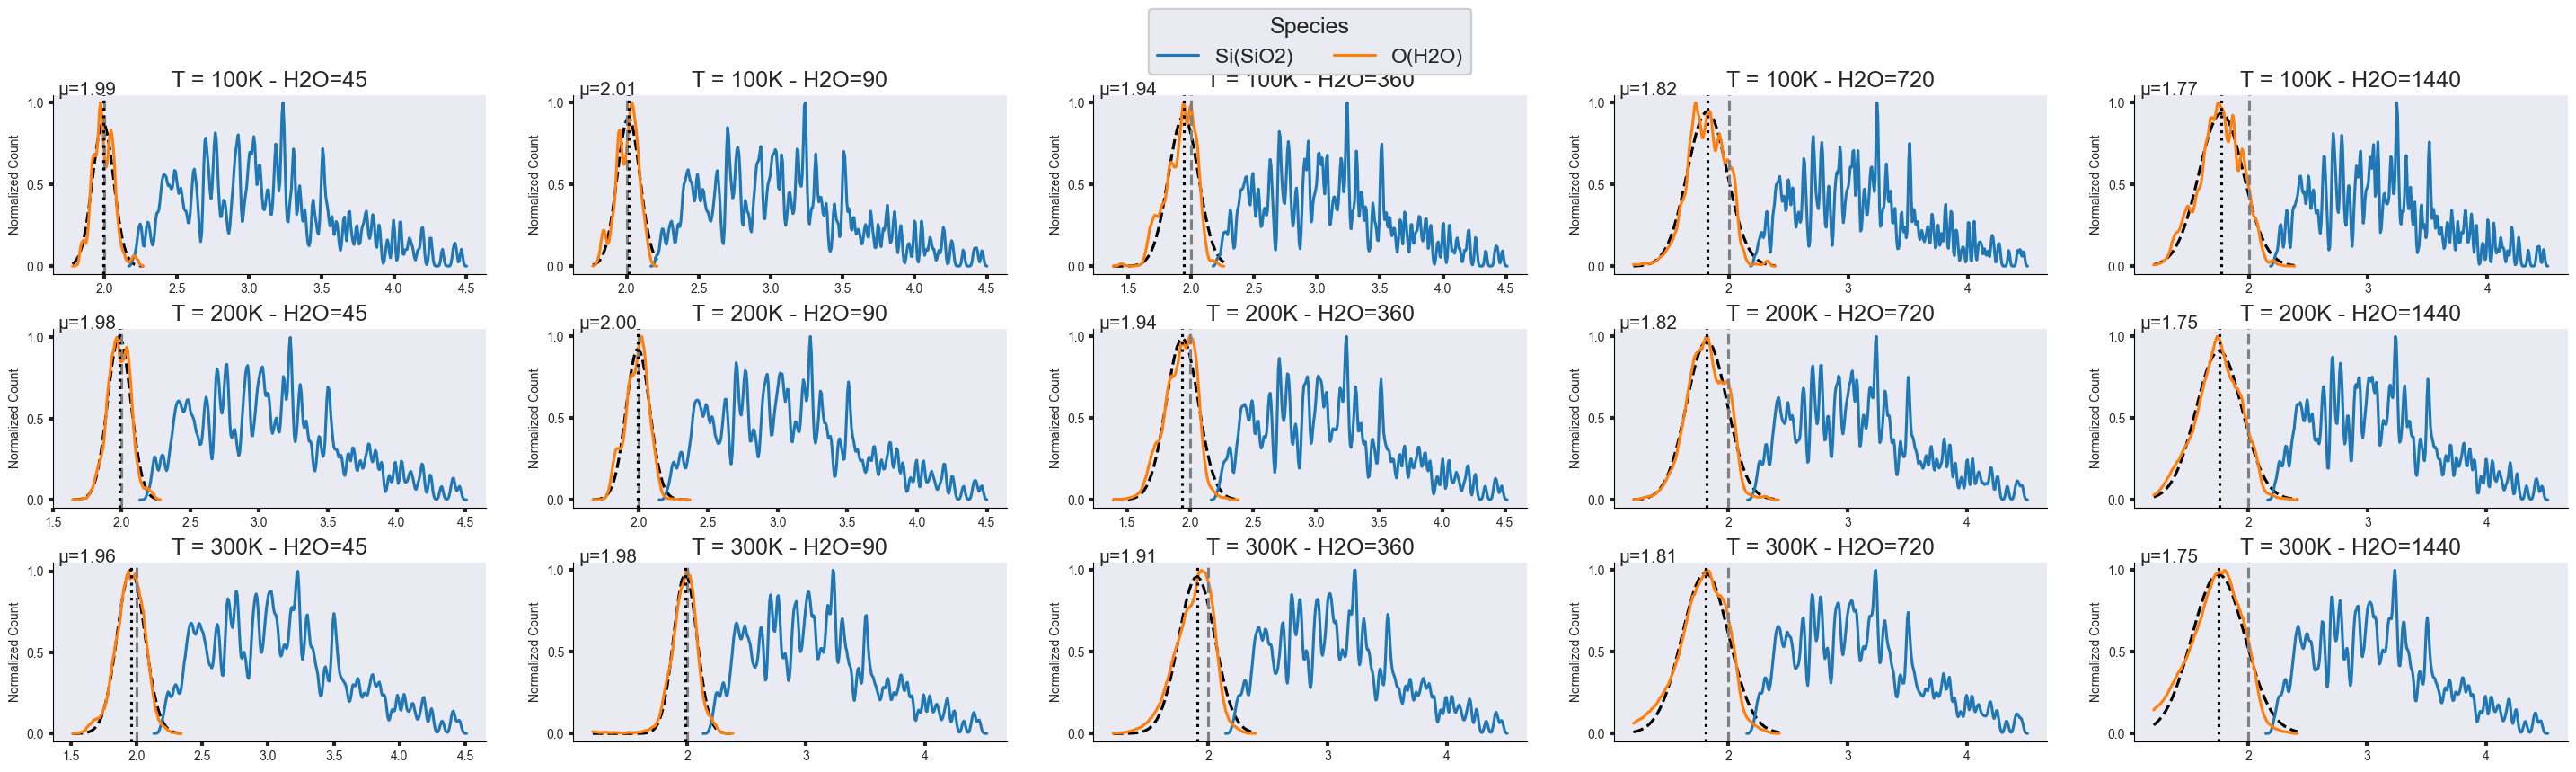

In [5]:

def func(x,  a, b,m):
    return a*np.exp(-b*(x-m)**2)


temperature_list=df_hist_gmx["Temperature (K)"].unique()
H2O_list=np.sort(df_hist_gmx["H2O"].unique())

fig, axs = plt.subplots(nrows=len(temperature_list),ncols=len(H2O_list),figsize=(7*len(H2O_list),3*len(temperature_list)))
sns.set_context("talk")


df_list=list()
for i, temperature in enumerate(temperature_list):
    for j, H2O in enumerate(H2O_list):
        ax=axs[i,j]
        df_tmp=df_hist_gmx.query("`Temperature (K)` == %d and H2O == %d "%(temperature,H2O))
    
        xdata, ydata = df_tmp.query("`Species` == 'O(H2O)' ")[["Distance (nm)","norm"]].values.T
        popt, pcov = curve_fit(func, xdata, ydata, p0=(1,1,2))
    #    popt, pcov = curve_fit(func, xdata, ydata,bounds=([0,0.001,14],[np.inf,np.inf,30]))
        xx=np.linspace(np.min(xdata),np.max(xdata))
        ax.plot(xx, func(xx, *popt), c="black",ls='--')
    
        sns.lineplot(data=df_tmp.query("`Species` == 'Si(SiO2)' or `Species` == 'O(H2O)' ") #.query("`Species` == 'O(H2O)'")
                     ,x="Distance (nm)"
                     ,y="norm"
                     ,hue="Species"
                     ,ax=ax
                     ,markers=True
                     ,legend=True if i==0 else False
                    )
        
        if i==0:
            sns.move_legend(ax,'lower center',bbox_to_anchor=(0.5,0.9125),ncol=4,bbox_transform=fig.transFigure)
        if i==4:
            ax.set_xlabel("Radial Distribution (nm)")
        else:
            ax.set_xlabel("")
        ax.set_ylabel("Normalized Count")
        ax.set_title("T = %dK - H2O=%d"%(temperature,H2O))
        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
        ax.tick_params(direction='out', width=3, bottom=True, left=True)
        ax.grid(False)
        ax.axvline(x=2,ymin=0,ymax=1,c='gray',ls='--')
        ax.axvline(x=popt[-1],ymin=0,ymax=1,c='black',ls=':')
        ax.text(0.0125,1,"μ=%.2f"%popt[-1],transform=ax.transAxes,fontsize="small")
        df_list.append({
            "Temperature (K)":temperature
            ,"H2O":H2O
            ,"$\mu_{H_2O}$":popt[2]
            ,"$\sigma_{H_2O}$":1/np.sqrt(2*popt[1])
            ,"$A_{H_2O}$":popt[0]
            ,"Force Field":"PoreMS"
        }
        )
        #ax.set_xlim(1.8,2.25)

df_fit_H2O_gmx=pd.DataFrame(df_list)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.3)

In [13]:
species_map={0:"H(Q3)",1:"H(Q2)",2:"O(Q3)",3:"O(Q2)",4:"O(SiO2)",5:"Si(SiO2)",6:"Si(Q3)",7:"O(H2O)",8:"H(H2O)"}

df_hist_list=list()
basepath="../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results"
for run_name in os.listdir(basepath):
    run_dir=os.path.join(basepath,run_name,"results")
    for rdf_dir in os.listdir(run_dir):
        if not "rdf" in rdf_dir:
            continue
        temperature=int(rdf_dir.split("_")[-1].replace("K",""))
        rdf_dir=os.path.join(run_dir,rdf_dir)
        H2O=int(run_name)
        print(rdf_dir,H2O,temperature)
        for species in species_map.keys():
            df_tmp=pd.read_csv(os.path.join(rdf_dir,"hist_%d.csv"%(species+1)),skiprows=1,skipfooter=1, engine='python',names=["Distance (nm)","count"]).query("count>0")
            df_tmp["Temperature (K)"]=temperature
            df_tmp["Species"]=species_map[species]
            df_tmp["H2O"]=H2O
            df_tmp["Force Field"]="ReaxFF2023"
            df_tmp["norm"]=df_tmp["count"]/df_tmp["count"].max()
            df_hist_list.append(df_tmp)
df_hist_lmp=pd.concat(df_hist_list,ignore_index=True)
df_hist_lmp

../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results\180\results\rdf_100K 180 100
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results\180\results\rdf_200K 180 200
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results\180\results\rdf_300K 180 300
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results\360\results\rdf_100K 360 100
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results\360\results\rdf_200K 360 200
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results\360\results\rdf_300K 360 300
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results\45\results\rdf_100K 45 100
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results\45\results\rdf_200K 45 200
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results\45\results\rdf_300K 45 300
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results\720\results\rdf_100K 720 100
../results/lammps/pore/beta_critobalite/reaxff

,Distance (nm),count,Temperature (K),Species,H2O,Force Field,norm
0,1.5996,2,100,H(Q3),180,ReaxFF2023,0.000031
1,1.6068,34,100,H(Q3),180,ReaxFF2023,0.000529
2,1.6140,264,100,H(Q3),180,ReaxFF2023,0.004106
3,1.6212,1226,100,H(Q3),180,ReaxFF2023,0.019066
4,1.6284,3197,100,H(Q3),180,ReaxFF2023,0.049719
...,...,...,...,...,...,...,...
22534,2.6220,104,300,H(H2O),90,ReaxFF2023,0.007249
22535,2.6292,63,300,H(H2O),90,ReaxFF2023,0.004391
22536,2.6364,34,300,H(H2O),90,ReaxFF2023,0.002370
22537,2.6436,23,300,H(H2O),90,ReaxFF2023,0.001603


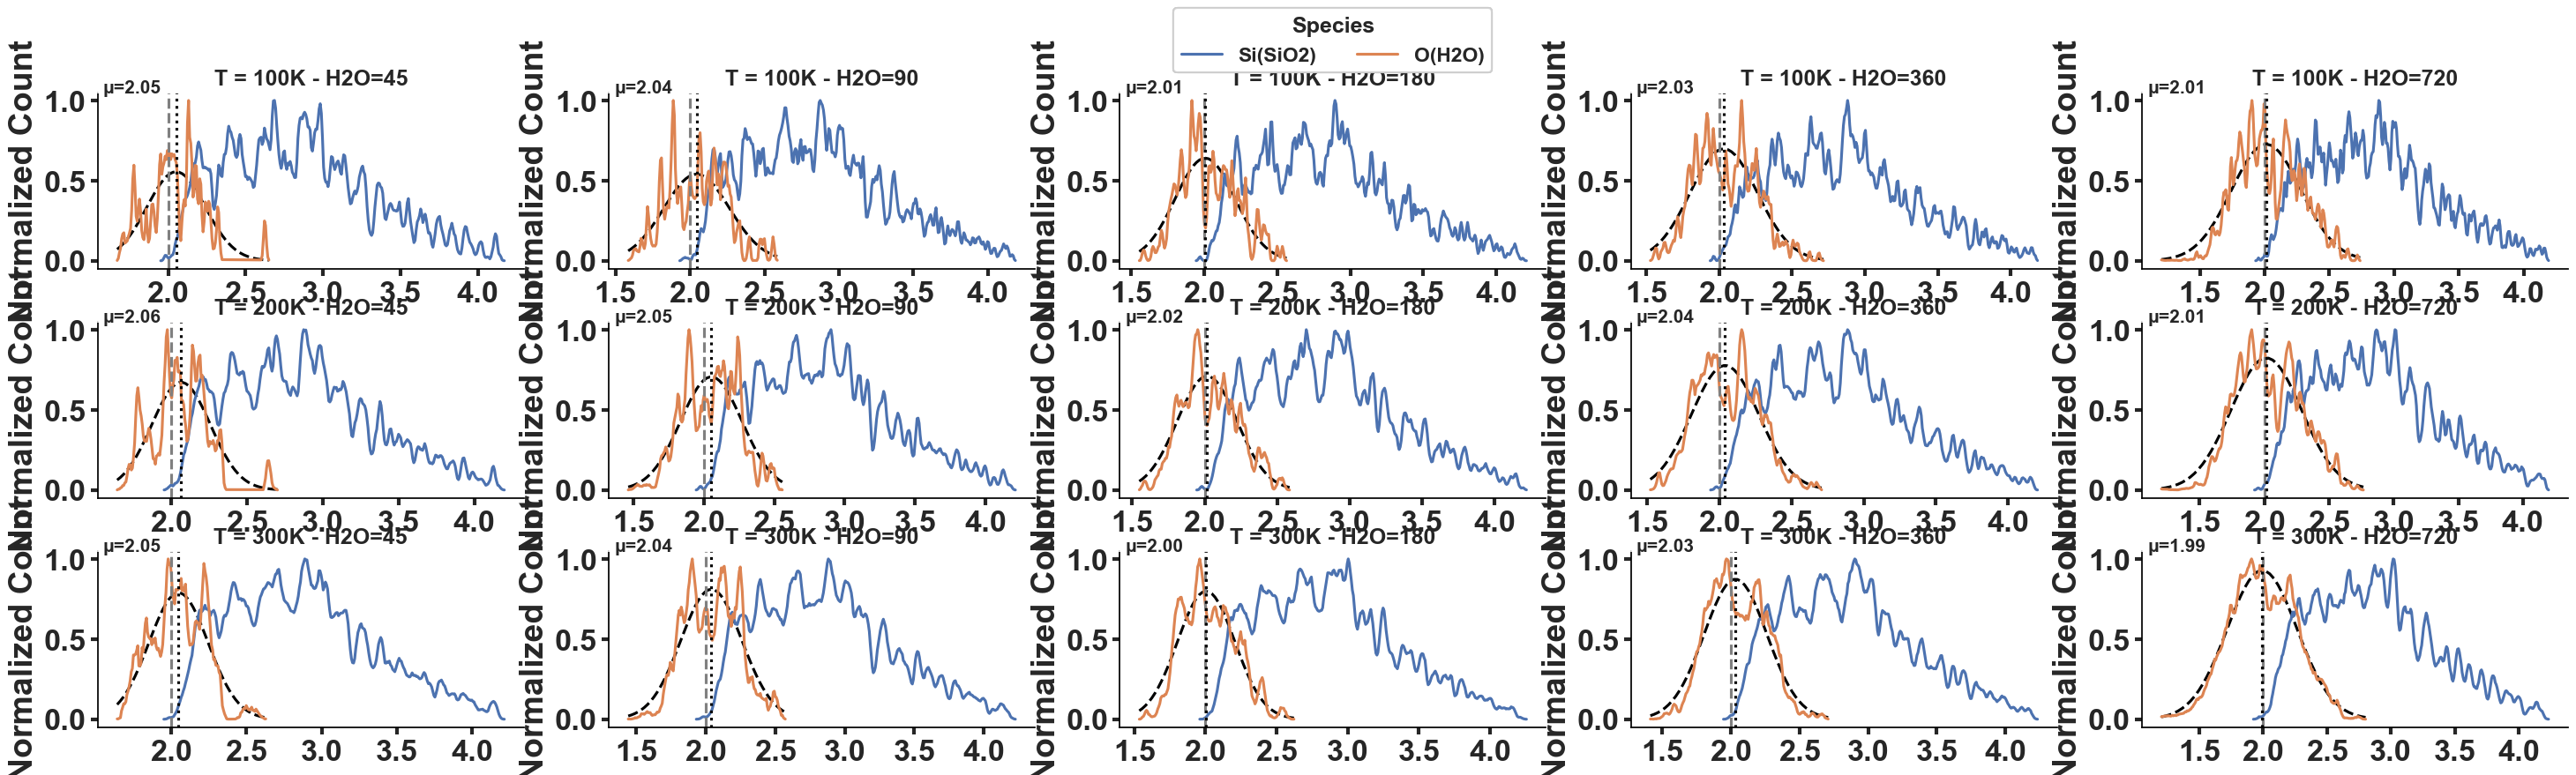

In [14]:

def func(x,  a, b,m):
    return a*np.exp(-b*(x-m)**2)


temperature_list=df_hist_lmp["Temperature (K)"].unique()
H2O_list=np.sort(df_hist_lmp["H2O"].unique())

fig, axs = plt.subplots(nrows=len(temperature_list),ncols=len(H2O_list),figsize=(7*len(H2O_list),3*len(temperature_list)))
sns.set_context("talk")


df_list=list()
for i, temperature in enumerate(temperature_list):
    for j, H2O in enumerate(H2O_list):
        ax=axs[i,j]
        df_tmp=df_hist_lmp.query("`Temperature (K)` == %d and H2O == %d "%(temperature,H2O))
    
        xdata, ydata = df_tmp.query("`Species` == 'O(H2O)' ")[["Distance (nm)","norm"]].values.T
        popt, pcov = curve_fit(func, xdata, ydata, p0=(1,1,2))
    #    popt, pcov = curve_fit(func, xdata, ydata,bounds=([0,0.001,14],[np.inf,np.inf,30]))
        xx=np.linspace(np.min(xdata),np.max(xdata))
        ax.plot(xx, func(xx, *popt), c="black",ls='--')
    
        sns.lineplot(data=df_tmp.query("`Species` == 'Si(SiO2)' or `Species` == 'O(H2O)' ") #.query("`Species` == 'O(H2O)'")
                     ,x="Distance (nm)"
                     ,y="norm"
                     ,hue="Species"
                     ,ax=ax
                     ,markers=True
                     ,legend=True if i==0 else False
                    )
        
        if i==0:
            sns.move_legend(ax,'lower center',bbox_to_anchor=(0.5,0.9125),ncol=4,bbox_transform=fig.transFigure)
        if i==4:
            ax.set_xlabel("Radial Distribution (nm)")
        else:
            ax.set_xlabel("")
        ax.set_ylabel("Normalized Count")
        ax.set_title("T = %dK - H2O=%d"%(temperature,H2O))
        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
        ax.tick_params(direction='out', width=3, bottom=True, left=True)
        ax.grid(False)
        ax.axvline(x=2,ymin=0,ymax=1,c='gray',ls='--')
        ax.axvline(x=popt[-1],ymin=0,ymax=1,c='black',ls=':')
        ax.text(0.0125,1,"μ=%.2f"%popt[-1],transform=ax.transAxes,fontsize="small")
        df_list.append({
            "Temperature (K)":temperature
            ,"H2O":H2O
            ,"$\mu_{H_2O}$":popt[2]
            ,"$\sigma_{H_2O}$":1/np.sqrt(2*popt[1])
            ,"$A_{H_2O}$":popt[0]
            ,"Force Field":"ReaxFF2023"
        }
        )
        #ax.set_xlim(1.8,2.25)

df_fit_H2O_lmp=pd.DataFrame(df_list)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.3)

In [15]:
df_hist=pd.concat([df_hist_gmx,df_hist_lmp],ignore_index=True)
df_fit_H2O=pd.concat([df_fit_H2O_gmx,df_fit_H2O_lmp],ignore_index=True)

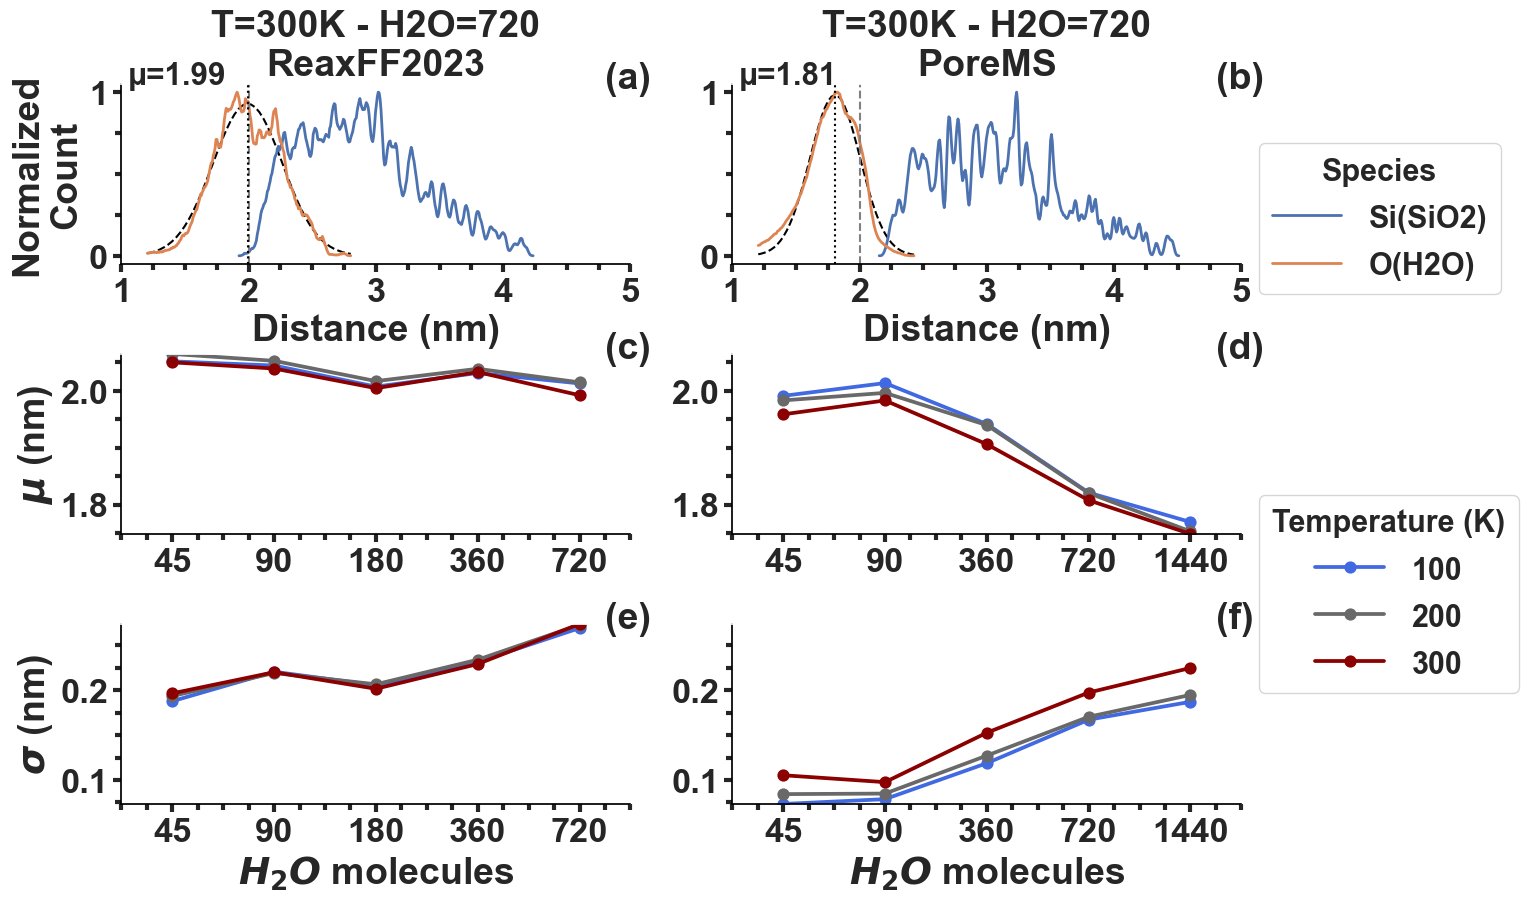

In [16]:
plt.rc('axes', linewidth=3, labelsize=22)
plt.rc('xtick', labelsize=22)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=22)  # fontsize of the y tick labels
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'  # Axis labels
plt.rcParams['axes.titleweight'] = 'bold' 

sns.set_theme(font_scale=2.25)
sns.set_style("white")

fig, axs = plt.subplots(nrows=3,ncols=2,figsize=(7*2,3*3))

labx=0.95
laby=0.975
index=["(%s)"%x for x in list("abcdefghijkl")]
for i,force_field in enumerate(["ReaxFF2023","PoreMS"]):
    ax=axs[0,i]
    ax.text(labx, laby, index[i],weight='bold' ,transform=ax.transAxes)

    df_tmp=df_hist.query("`Force Field` == '%s' and H2O == 720 and `Temperature (K)`== 300 "%force_field)
    xdata, ydata = df_tmp.query("`Species` == 'O(H2O)' ")[["Distance (nm)","norm"]].values.T
    popt, pcov = curve_fit(func, xdata, ydata, p0=(1,1,2))
    xx=np.linspace(np.min(xdata),np.max(xdata))
    ax.plot(xx, func(xx, *popt), c="black",ls='--')
    
    sns.lineplot(data=df_tmp.query("`Species` == 'Si(SiO2)' or `Species` == 'O(H2O)' ") #.query("`Species` == 'O(H2O)'")
                 ,x="Distance (nm)"
                 ,y="norm"
                 ,hue="Species"
                 ,ax=ax
                 ,markers=True
                 ,legend=i==0 
                 ,lw=2
                )
    if i==0:
        sns.move_legend(ax,'center left',bbox_to_anchor=(0.9,0.75),ncol=1,bbox_transform=fig.transFigure)
    
    apply_ax_format(ax,xlabel="Distance (nm)",ylabel="Normalized\nCount",title="T=300K - H2O=720\n%s"%force_field,legend=i==0)
    if i > 0:
        ax.set_ylabel("")
    
    
    ax.axvline(x=2,ymin=0,ymax=1,c='gray',ls='--')
    ax.axvline(x=popt[-1],ymin=0,ymax=1,c='black',ls=':')
    ax.text(0.0125,1,"μ=%.2f"%popt[-1],transform=ax.transAxes,fontsize="small")
    ax.set_xlim(1,5)

for i,force_field in enumerate(["ReaxFF2023","PoreMS"]):
    ax=axs[1,i]
    ax.text(labx, laby, index[2+i],weight='bold' ,transform=ax.transAxes)

    df_tmp=df_fit_H2O.query("`Force Field` == '%s' "%force_field)
    
    sns.pointplot(data=df_tmp
                 ,x="H2O"
                 ,y="$\\mu_{H_2O}$"
                 ,hue="Temperature (K)"
                 ,ax=ax
                 ,palette=["royalblue","dimgrey","darkred"]
                 ,legend=i==0
                )
    if i==0:
        sns.move_legend(ax,'center left',bbox_to_anchor=(0.9,1.0/3.0),ncol=1,bbox_transform=fig.transFigure)
    
    apply_ax_format(ax,ylabel="$\mu$ (nm)",legend=i==0)
    if i > 0:
        ax.set_ylabel("")
    ax.set_ylim(df_fit_H2O["$\\mu_{H_2O}$"].min(),df_fit_H2O["$\\mu_{H_2O}$"].max())
    
    
for i,force_field in enumerate(["ReaxFF2023","PoreMS"]):
    ax=axs[2,i]
    ax.text(labx, laby, index[4+i],weight='bold' ,transform=ax.transAxes)
    df_tmp=df_fit_H2O.query("`Force Field` == '%s' "%force_field)
    
    sns.pointplot(data=df_tmp
                 ,x="H2O"
                 ,y="$\\sigma_{H_2O}$"
                 ,hue="Temperature (K)"
                 ,ax=ax
                 ,palette=["royalblue","dimgrey","darkred"]
                 ,legend=False
                )
    
    apply_ax_format(ax,xlabel="$H_2O$ molecules",ylabel="$\sigma$ (nm)")
    if i > 0:
        ax.set_ylabel("")
    ax.set_ylim(df_fit_H2O["$\\sigma_{H_2O}$"].min(),df_fit_H2O["$\\sigma_{H_2O}$"].max())
    

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.5)

plt.savefig("../figures/fig9.pdf", pad_inches=0.2,bbox_inches="tight")

In [ ]:
df_fit_H2O